# SaaS Funnel, Cohort Retention & LTV:CAC Analysis

A synthetic but structurally realistic SaaS product dataset — signups, a
3-step conversion funnel (signup -> activated -> subscribed), and ongoing
subscriptions with churn — analysed with the three questions a growth/data
analyst is actually asked:

1. **Where does the funnel leak, and does it differ by acquisition channel?**
2. **Do subscribers stick around, and does retention differ by channel?**
3. **Which channel is actually worth the marketing spend** — not by signup
   volume, but by LTV:CAC?

Every query lives in `sql/*.sql`; this notebook executes them and reads the
results into a single business recommendation.

In [1]:
import sys
sys.path.append('..')
import warnings
warnings.filterwarnings('ignore')

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

from src.build_db import DB_PATH, build_db
from src.run_queries import split_statements

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SQL_DIR = Path('../sql')

build_db()  # regenerate so this notebook is fully reproducible standalone
conn = sqlite3.connect(DB_PATH)

def run(file_stem, query_index=0):
    stmt = split_statements((SQL_DIR / f'{file_stem}.sql').read_text())[query_index][1]
    return pd.read_sql(stmt, conn)

print('Database ready.')

Database ready.


## 1. Funnel conversion — where does the funnel leak?

`sql/01_funnel_conversion.sql`

In [2]:
overall_funnel = run('01_funnel_conversion', 0)
overall_funnel

,signups,activated,subscribed
0,6000,2811,790


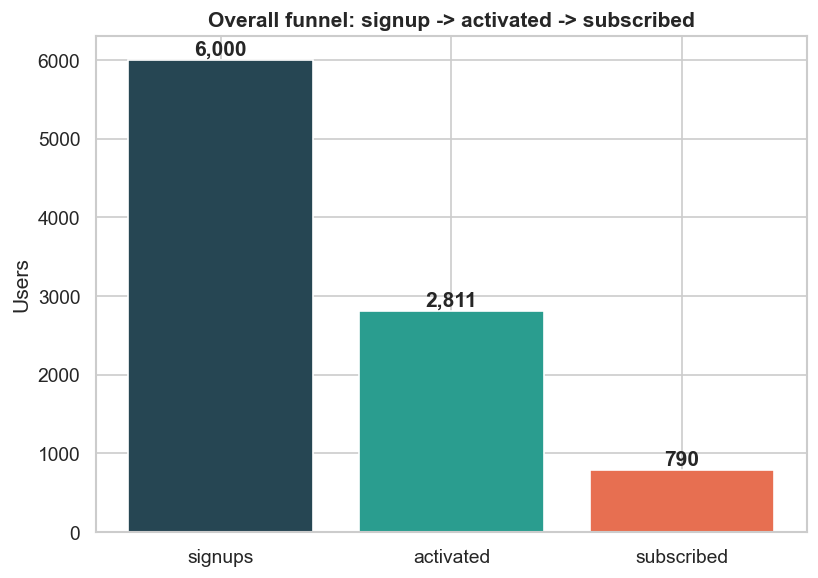

Activation rate: 46.9% | Subscribe-given-activated: 28.1% | Overall conversion: 13.2%


In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
stages = ['signups', 'activated', 'subscribed']
values = overall_funnel.iloc[0][stages].values
ax.bar(stages, values, color=['#264653', '#2a9d8f', '#e76f51'])
for i, v in enumerate(values):
    ax.text(i, v + 60, f'{v:,}', ha='center', fontweight='bold')
ax.set_ylabel('Users')
ax.set_title('Overall funnel: signup -> activated -> subscribed', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_overall_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Activation rate: {values[1]/values[0]:.1%} | Subscribe-given-activated: {values[2]/values[1]:.1%} | Overall conversion: {values[2]/values[0]:.1%}")

In [4]:
by_channel = run('01_funnel_conversion', 1)
by_channel

,acquisition_channel,signups,activated,subscribed,activation_rate_pct,subscribe_given_activated_pct,overall_conversion_pct
0,Referral,483,315,158,65.2,50.2,32.7
1,Organic Search,1506,822,297,54.6,36.1,19.7
2,Content/SEO,690,431,121,62.5,28.1,17.5
3,Paid Ads,2078,816,154,39.3,18.9,7.4
4,Social Media,1243,427,60,34.4,14.1,4.8


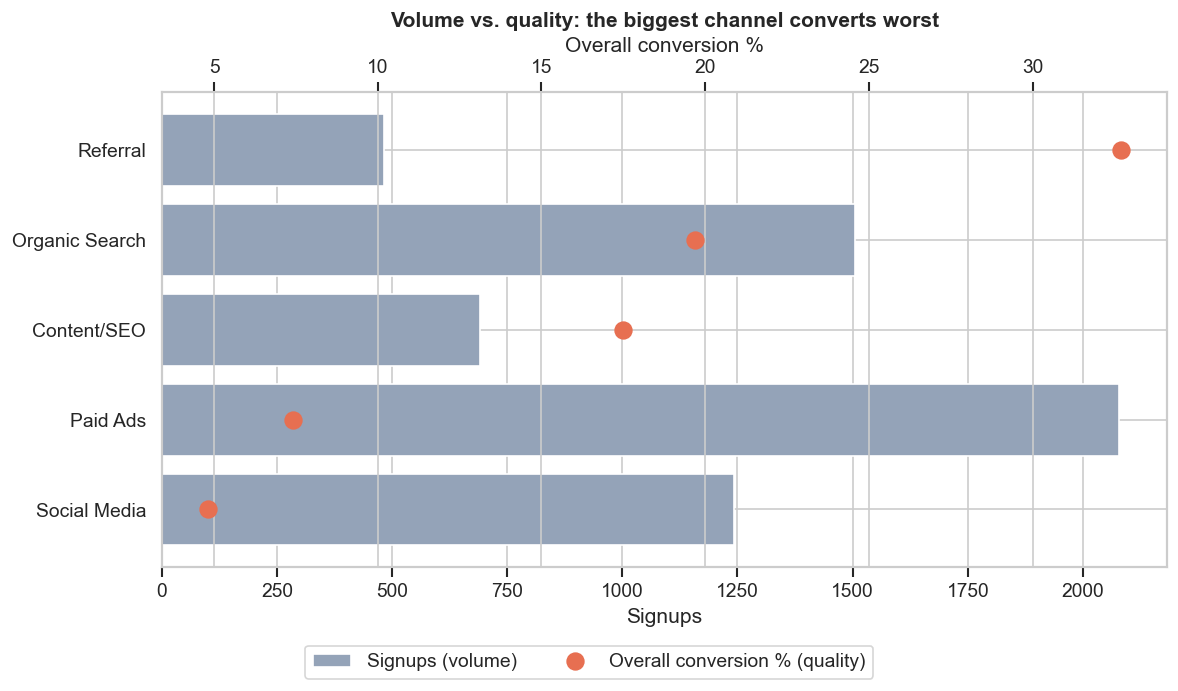

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ordered = by_channel.sort_values('overall_conversion_pct')
bars = ax.barh(ordered['acquisition_channel'], ordered['signups'], color='#94a3b8', label='Signups (volume)')
ax2 = ax.twiny()
ax2.plot(ordered['overall_conversion_pct'], ordered['acquisition_channel'], marker='o', color='#e76f51',
         linewidth=0, markersize=10, label='Overall conversion % (quality)')
ax.set_xlabel('Signups'); ax2.set_xlabel('Overall conversion %')
ax.set_title('Volume vs. quality: the biggest channel converts worst', fontweight='bold')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_volume_vs_quality.png', dpi=150, bbox_inches='tight')
plt.show()

**Paid Ads brings the most signups (2,078) but converts worst (7.4%
overall); Referral brings the fewest (483) but converts best (32.7%
overall)** — a 4.4x conversion gap that raw signup-volume reporting would
completely miss.

## 2. Cohort retention — do subscribers stick around?

`sql/02_cohort_retention.sql` — subscription-survival triangle, restricted
to cohorts with 15+ subscribers so percentages aren't noise from a handful
of people.

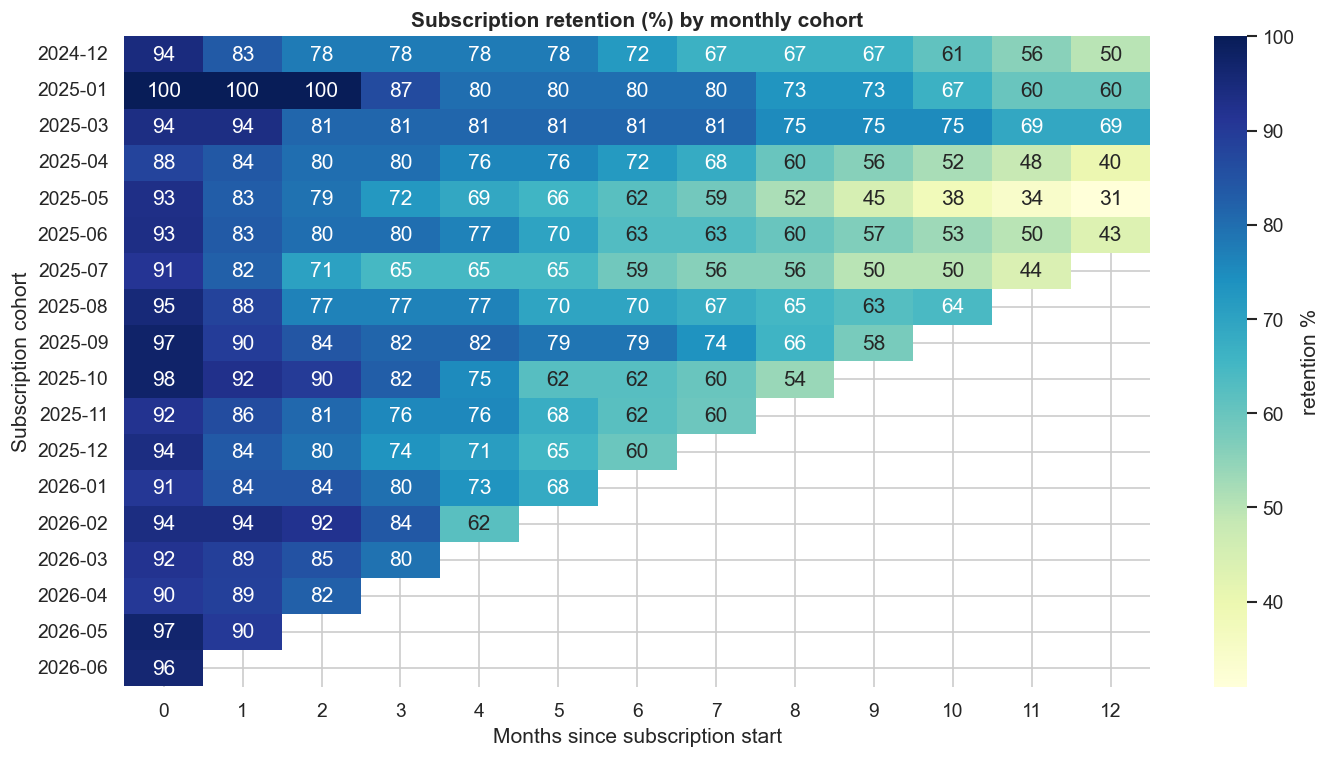

In [6]:
cohort = run('02_cohort_retention', 0)
cohort_stable = cohort[cohort['cohort_size_observable'] >= 15]
pivot = cohort_stable.pivot(index='cohort_month', columns='month_offset', values='retention_pct')

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'retention %'}, ax=ax)
ax.set_xlabel('Months since subscription start'); ax.set_ylabel('Subscription cohort')
ax.set_title('Subscription retention (%) by monthly cohort', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_cohort_retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. LTV:CAC — which channel is actually worth the spend?

`sql/03_ltv_and_recommendation.sql` — this is where funnel quality and
retention combine into a single number a budget decision can be made on.

In [7]:
ltv = run('03_ltv_and_recommendation', 0)
ltv

,acquisition_channel,n_subscribers,avg_monthly_fee,avg_tenure_months,avg_ltv,estimated_cac,ltv_to_cac_ratio
0,Referral,158,45.42,6.08,275.12,10.0,27.51
1,Content/SEO,121,32.50,6.28,203.15,15.0,13.54
2,Organic Search,297,35.40,5.82,205.93,20.0,10.30
3,Social Media,60,25.23,4.50,114.35,35.0,3.27
4,Paid Ads,154,30.22,4.45,132.55,45.0,2.95


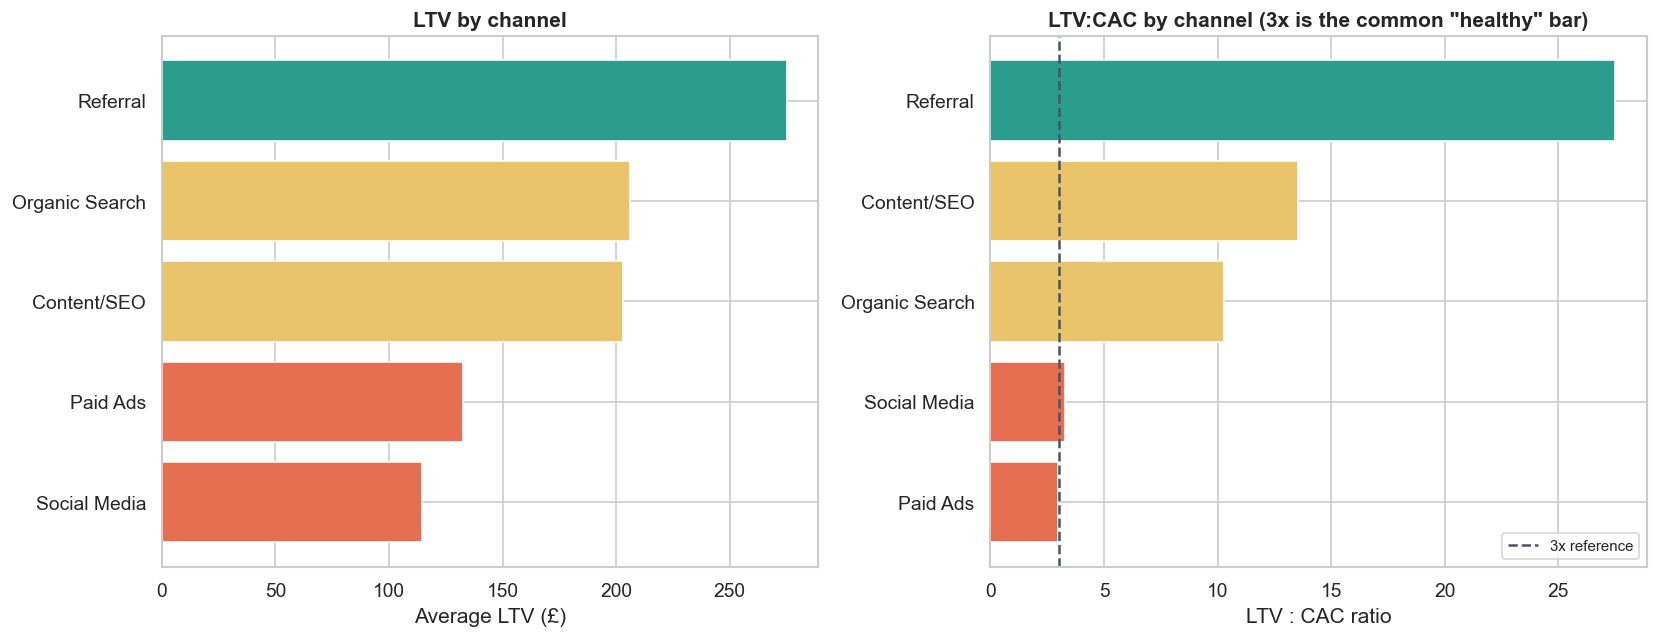

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
ordered = ltv.sort_values('avg_ltv')
colors = ['#e76f51' if r < 5 else '#e9c46a' if r < 15 else '#2a9d8f' for r in ordered['ltv_to_cac_ratio']]

axes[0].barh(ordered['acquisition_channel'], ordered['avg_ltv'], color=colors)
axes[0].set_xlabel('Average LTV (£)')
axes[0].set_title('LTV by channel', fontweight='bold')

ordered2 = ltv.sort_values('ltv_to_cac_ratio')
colors2 = ['#e76f51' if r < 5 else '#e9c46a' if r < 15 else '#2a9d8f' for r in ordered2['ltv_to_cac_ratio']]
axes[1].barh(ordered2['acquisition_channel'], ordered2['ltv_to_cac_ratio'], color=colors2)
axes[1].set_xlabel('LTV : CAC ratio')
axes[1].set_title('LTV:CAC by channel (3x is the common "healthy" bar)', fontweight='bold')
axes[1].axvline(3, color='#475569', ls='--', lw=1.5, label='3x reference')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_ltv_cac.png', dpi=150, bbox_inches='tight')
plt.show()

## Recommendation

1. **Paid Ads is the volume leader and the LTV:CAC laggard** — 2,078
   signups but only 2.95x LTV:CAC, barely above the commonly-used 3x
   "healthy SaaS" bar, once its high CAC (£45) and high churn are both
   priced in.
2. **Referral is the opposite** — only 483 signups, but 32.7% overall
   conversion, the longest average tenure, and a 27.5x LTV:CAC ratio — 9x
   better than Paid Ads.
3. **Concrete action**: shift incremental acquisition budget from Paid Ads
   toward scaling the Referral program (e.g. a stronger referral incentive
   or in-app prompts at the activation step, where Referral users are
   already converting at 2.7x Paid Ads' rate). This doesn't mean cutting
   Paid Ads to zero — it's still the primary volume channel — but marginal
   budget is better spent buying more Referral-quality growth than more
   Paid-Ads-quality growth.
4. **Caveat, stated honestly**: CAC figures are illustrative assumptions
   (documented in `sql/03_ltv_and_recommendation.sql` and matched exactly
   to the generator), not pulled from a real ads platform — the
   *methodology* (funnel by channel -> retention by channel -> LTV:CAC) is
   the reusable part; the specific ratios would need real spend data to
   action directly.